In [2]:
import pandas as pd
import numpy as np
import time
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

In [3]:
import importlib
import feature_engineer
importlib.reload(feature_engineer)

<module 'feature_engineer' from '/Users/jiashenwang/Desktop/Lucas_Systems_Capstone_Project/Model_Jiashen/feature_engineer.py'>

In [4]:
# Configurations
warehouses = ["OE", "OF"]
work_codes = ["10", "20", "30"]
max_time = 300
models = []
results = []

In [5]:
from feature_engineer import get_engineered_df

for wh in warehouses:
    DATA_PATH = f"../data/processed/{wh.lower()}_detailed.parquet"
    for wc in work_codes:
        print(f"--- Training Model for {wh} | WC {wc} ---")
        
        # 1. Preprocess
        df, features, cat_cols = get_engineered_df(DATA_PATH, warehouse=wh, work_code=wc, max_time=max_time)
        # remove distance from features
        # features = [f for f in features if f != "Travel_Distance"]
        
        # 2. Prepare Data (One-Hot Encoding)
        X = pd.get_dummies(df[features], columns=cat_cols, drop_first=True)
        y = df["Time_Delta_sec"]
        
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        # 3. Model Training & Timing
        start_time = time.time()
        model = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)
        end_time = time.time()
        models.append(model)
        
        # 4. Evaluation
        preds = model.predict(X_test)
        r2 = r2_score(y_test, preds)
        mae = mean_absolute_error(y_test, preds)
        runtime = end_time - start_time
        
        # 5. Store Results
        results.append({
            "Warehouse": wh,
            "WorkCode": wc,
            "Train_Rows": len(X_train),
            "R^2": round(r2, 4),
            "MAE": round(mae, 2),
            "Runtime_Sec": round(runtime, 2)
        })

# Display Clean Results Table
results_df = pd.DataFrame(results)
display(results_df)

--- Training Model for OE | WC 10 ---
--- Training Model for OE | WC 20 ---
--- Training Model for OE | WC 30 ---
--- Training Model for OF | WC 10 ---
--- Training Model for OF | WC 20 ---
--- Training Model for OF | WC 30 ---


,Warehouse,WorkCode,Train_Rows,R^2,MAE,Runtime_Sec
0,OE,10,3265,0.2801,35.46,0.43
1,OE,20,17067,0.6552,16.60,0.56
2,OE,30,52238,0.3816,22.40,0.86
3,OF,10,3740,0.4297,30.21,0.31
4,OF,20,32110,0.6318,17.05,0.55
5,OF,30,60366,0.3789,28.55,0.81


In [6]:
models_nodist = []
results_nodist = []

for wh in warehouses:
    DATA_PATH = f"../data/processed/{wh.lower()}_detailed.parquet"
    for wc in work_codes:
        print(f"--- Training Model for {wh} | WC {wc} ---")
        
        # 1. Preprocess
        df, features, cat_cols = get_engineered_df(DATA_PATH, warehouse=wh, work_code=wc, max_time=max_time)
        # remove distance, "same_aisle", "same_lockey", "diff_level" from features
        features = [f for f in features if f not in ["Travel_Distance", "same_aisle", "same_lockey", "diff_level"]]
        cat_cols = [col for col in cat_cols if col not in ["same_aisle", "same_lockey", "diff_level"]]
        
        # 2. Prepare Data (One-Hot Encoding)
        X = pd.get_dummies(df[features], columns=cat_cols, drop_first=True)
        y = df["Time_Delta_sec"]
        
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        # 3. Model Training & Timing
        start_time = time.time()
        model = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)
        end_time = time.time()
        models_nodist.append(model)
        
        # 4. Evaluation
        preds = model.predict(X_test)
        r2 = r2_score(y_test, preds)
        mae = mean_absolute_error(y_test, preds)
        runtime = end_time - start_time
        
        # 5. Store Results
        results_nodist.append({
            "Warehouse": wh,
            "WorkCode": wc,
            "Train_Rows": len(X_train),
            "R^2": round(r2, 4),
            "MAE": round(mae, 2),
            "Runtime_Sec": round(runtime, 2)
        })

# Display Clean Results Table
results_df_nodist = pd.DataFrame(results_nodist)
display(results_df_nodist)

--- Training Model for OE | WC 10 ---
--- Training Model for OE | WC 20 ---
--- Training Model for OE | WC 30 ---
--- Training Model for OF | WC 10 ---
--- Training Model for OF | WC 20 ---
--- Training Model for OF | WC 30 ---


,Warehouse,WorkCode,Train_Rows,R^2,MAE,Runtime_Sec
0,OE,10,3265,-0.1514,47.64,0.36
1,OE,20,17067,-0.0308,40.29,0.47
2,OE,30,52238,0.0983,27.72,0.80
3,OF,10,3740,-0.0312,47.77,0.28
4,OF,20,32110,0.1044,36.63,0.61
5,OF,30,60366,0.0775,35.56,0.84


In [7]:
# Append MAE column of nodist to original results_df, right after MAE column and befoire Runtime_Sec, also add percentage increase
display_df = results_df.copy()
display_df["MAE_noDist"] = results_df_nodist["MAE"]
display_df["MAE_Increase(%)"] = ((display_df["MAE_noDist"] - display_df["MAE"]) / display_df["MAE"] * 100).round(2)
# move Runtime_Sec column to the end
cols = list(display_df.columns)
cols.append(cols.pop(cols.index("Runtime_Sec")))
display_df = display_df[cols]
display(display_df) 

,Warehouse,WorkCode,Train_Rows,R^2,MAE,MAE_noDist,MAE_Increase(%),Runtime_Sec
0,OE,10,3265,0.2801,35.46,47.64,34.35,0.43
1,OE,20,17067,0.6552,16.60,40.29,142.71,0.56
2,OE,30,52238,0.3816,22.40,27.72,23.75,0.86
3,OF,10,3740,0.4297,30.21,47.77,58.13,0.31
4,OF,20,32110,0.6318,17.05,36.63,114.84,0.55
5,OF,30,60366,0.3789,28.55,35.56,24.55,0.81


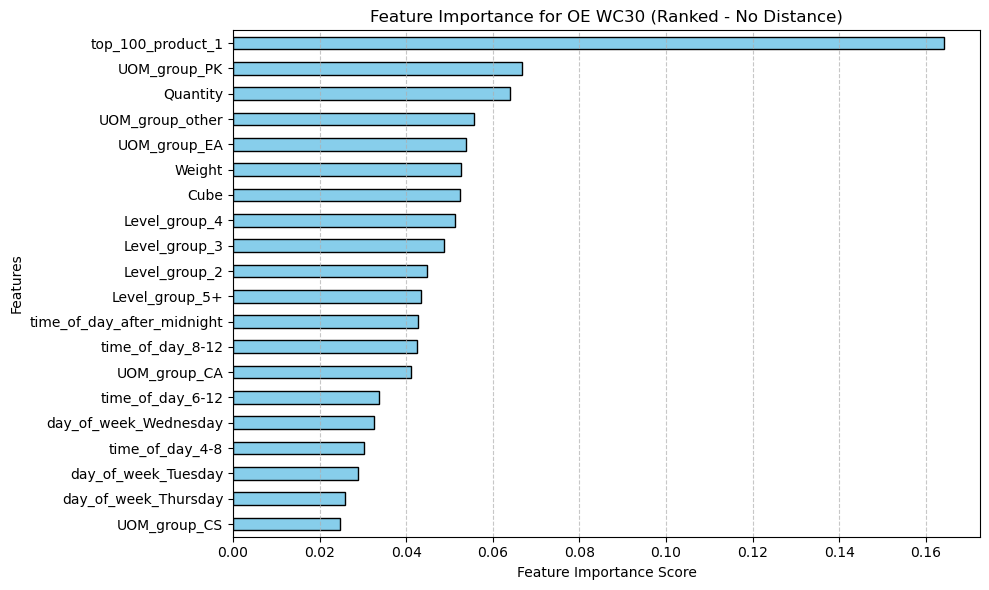

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Select the model
oe_wc30_model_nodist = models_nodist[2]

# 2. Create a Series using the model's internal feature names to prevent index mismatch
feat_importances = pd.Series(
    oe_wc30_model_nodist.feature_importances_, 
    index=oe_wc30_model_nodist.feature_names_in_
).sort_values(ascending=True)

# 3. Plotting
plt.figure(figsize=(10, 6))
feat_importances.plot(kind='barh', color='skyblue', edgecolor='black')

plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance for OE WC30 (Ranked - No Distance)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()